In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('stock_dataset.csv')

In [9]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [10]:
data.head()

,Open,High,Low,Volume,MarketSentiment,Close
0,249.816048,388.914241,121.249548,252041.556765,0.414477,224.311194
1,480.285723,137.862984,441.021163,350731.305129,-0.694922,256.853495
2,392.797577,172.732921,282.100949,259309.435849,0.152577,234.000179
3,339.463394,504.349385,410.582986,179832.280381,0.213430,345.298912
4,162.407456,372.893077,208.019840,208572.283991,-0.151739,208.360369


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 49)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 5), (40, 5), (160,), (40,))

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
from sklearn.metrics import r2_score, mean_squared_error
yhat_train = model.predict(X_train)
r2_tr = r2_score(y_train, yhat_train)
mse_tr = mean_squared_error(y_train, yhat_train)
rmse_tr = np.sqrt(mse_tr)

In [31]:
yhat_test = model.predict(X_test)
r2_ts = r2_score(y_test, yhat_test)
mse_ts = mean_squared_error(y_test, yhat_test)
rmse_ts = np.sqrt(mse_ts)

In [32]:
print(f'r2_score: {r2_tr}\nmse: {mse_tr}\nrmse: {rmse_tr}')

r2_score: 0.9744773341667856
mse: 77.17365082730846
rmse: 8.784853489234095


In [34]:
print(f'r2_score: {r2_ts}\nmse: {mse_ts}\nrmse: {rmse_ts}')

r2_score: 0.9645655329818188
mse: 115.7193496901471
rmse: 10.75729286066653


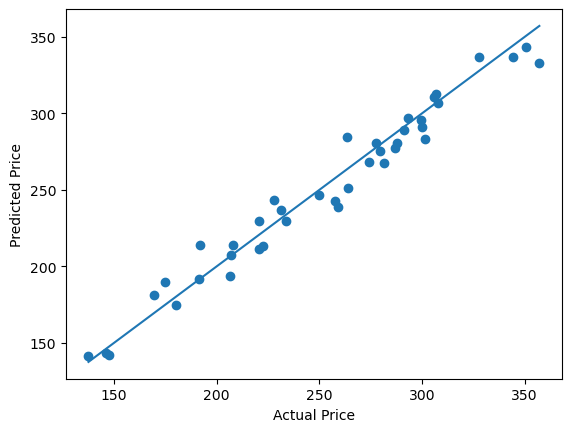

In [37]:
plt.scatter(y_test, yhat_test)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()